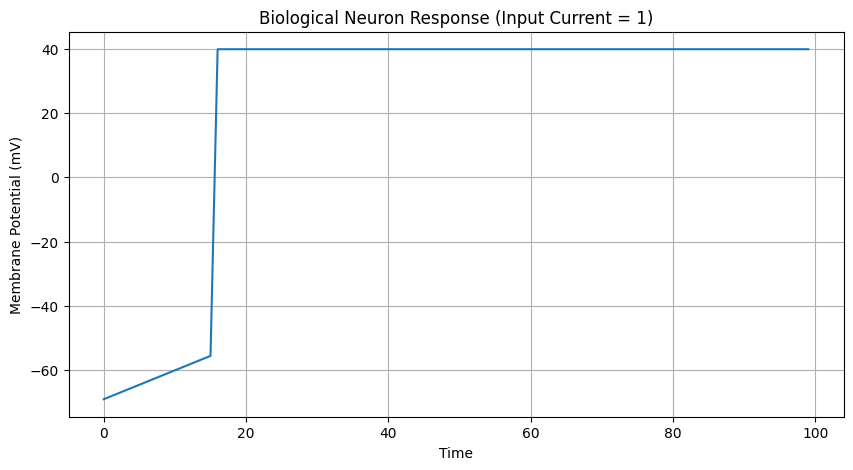

In [1]:
import numpy as np
import matplotlib.pyplot as plt

class BiologicalNeuron:
    """Simulates basic biological neuron characteristics"""

    def __init__(self):
        self.resting_potential = -70  # mV
        self.threshold = -55          # mV
        self.peak_potential = 40      # mV

    def simulate_response(self, input_current, time_steps=100):
        membrane_potential = self.resting_potential
        membrane_potentials = []

        for t in range(time_steps):
            # membrane potential increases with input current
            membrane_potential += input_current

            # if threshold is reached, generate action potential
            if membrane_potential >= self.threshold:
                membrane_potential = self.peak_potential

            # simple decay back down
            membrane_potential -= 0.1

            membrane_potentials.append(membrane_potential)

        # plot the response
        plt.figure(figsize=(10, 5))
        plt.plot(membrane_potentials)
        plt.xlabel("Time")
        plt.ylabel("Membrane Potential (mV)")
        plt.title(f"Biological Neuron Response (Input Current = {input_current})")
        plt.grid(True)
        plt.show()

# Example usage
neuron = BiologicalNeuron()
neuron.simulate_response(1)

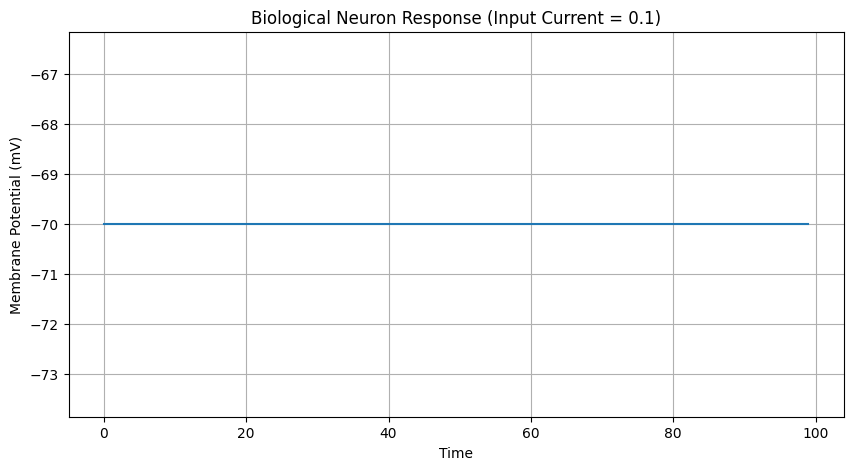

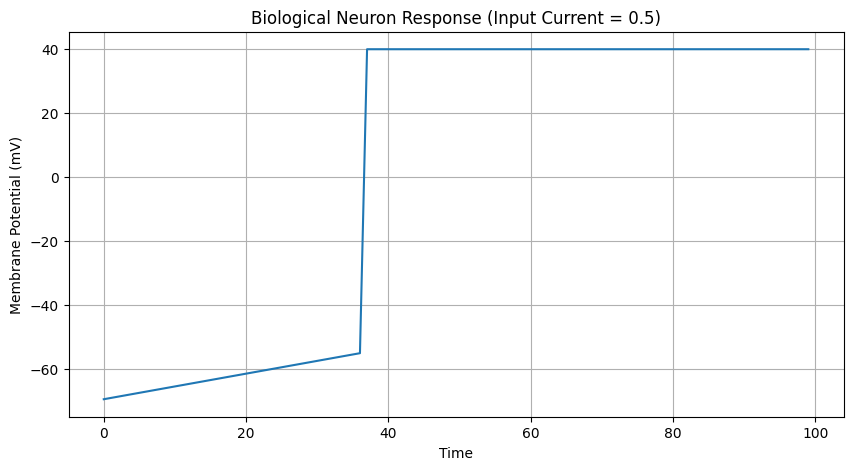

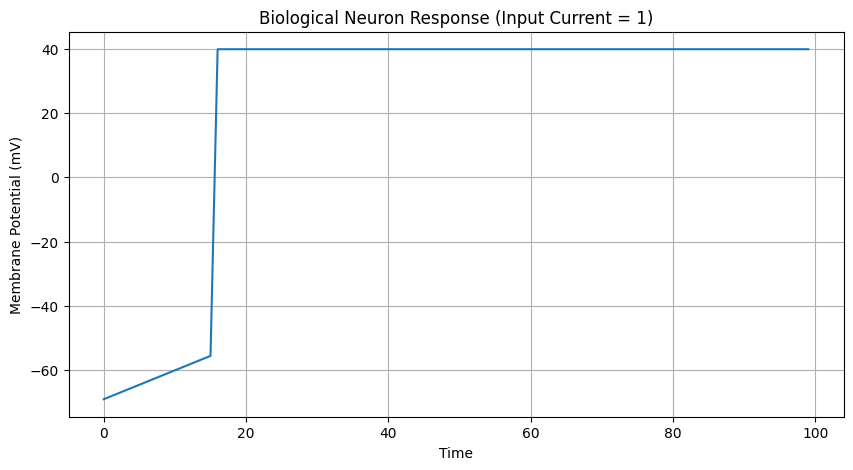

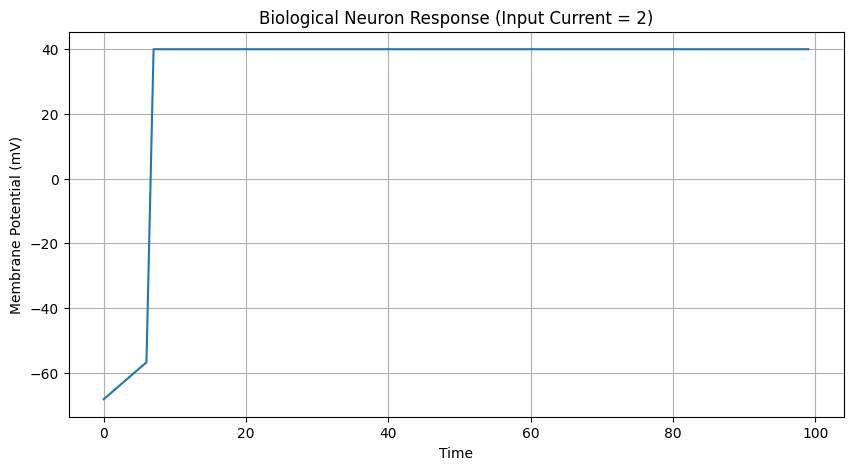

In [2]:
# Test different input currents
neuron = BiologicalNeuron()

inputs = [0.1, 0.5, 1, 2]

for current in inputs:
    neuron.simulate_response(current)

In [3]:
import numpy as np

class ArtificialNeuron:
    """Implements artificial neuron for comparison"""

    def __init__(self, num_inputs):
        self.weights = np.random.randn(num_inputs)
        self.bias = 0

    def activate(self, inputs):
        # weighted sum
        weighted_sum = np.dot(self.weights, inputs) + self.bias

        # sigmoid activation
        output = 1 / (1 + np.exp(-weighted_sum))

        return output


# Example usage
neuron = ArtificialNeuron(3)

inputs = np.array([0.5, 0.2, 0.8])

output = neuron.activate(inputs)

print("Output:", output)

Output: 0.7403489232715582


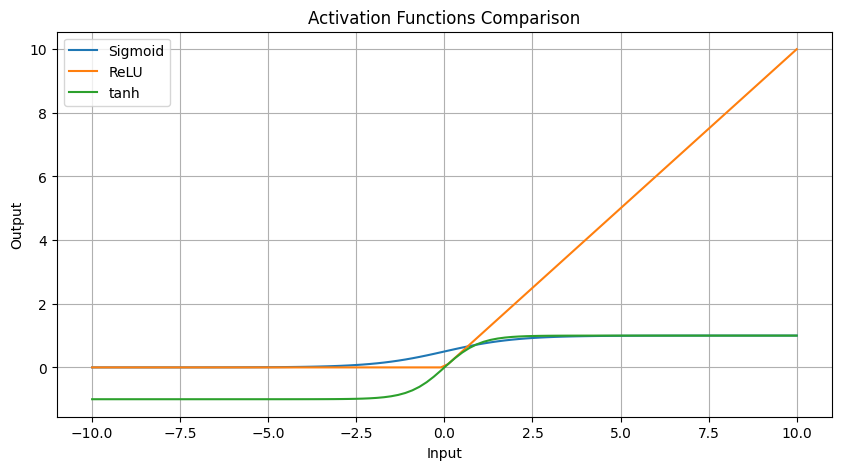

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Create input range
x = np.linspace(-10, 10, 100)

# Activation functions
sigmoid = 1 / (1 + np.exp(-x))
relu = np.maximum(0, x)
tanh = np.tanh(x)

# Plot them
plt.figure(figsize=(10,5))
plt.plot(x, sigmoid, label="Sigmoid")
plt.plot(x, relu, label="ReLU")
plt.plot(x, tanh, label="tanh")

plt.title("Activation Functions Comparison")
plt.xlabel("Input")
plt.ylabel("Output")
plt.legend()
plt.grid(True)
plt.show()

In [5]:
class SimpleNetwork:
    def __init__(self):
        # first layer neuron (takes 2 inputs)
        self.neuron1 = ArtificialNeuron(2)

        # second layer neuron (takes output of neuron1)
        self.neuron2 = ArtificialNeuron(1)

    def forward(self, inputs):
        # pass inputs through first neuron
        out1 = self.neuron1.activate(inputs)

        # pass result into second neuron
        out2 = self.neuron2.activate(np.array([out1]))

        return out2


# Test the network
network = SimpleNetwork()

inputs_list = [
    np.array([0.1, 0.2]),
    np.array([0.5, 0.5]),
    np.array([1.0, 1.0])
]

for inputs in inputs_list:
    output = network.forward(inputs)
    print(f"Inputs: {inputs} → Output: {output}")

Inputs: [0.1 0.2] → Output: 0.4558572971278141
Inputs: [0.5 0.5] → Output: 0.4513995654096354
Inputs: [1. 1.] → Output: 0.44384805993989485


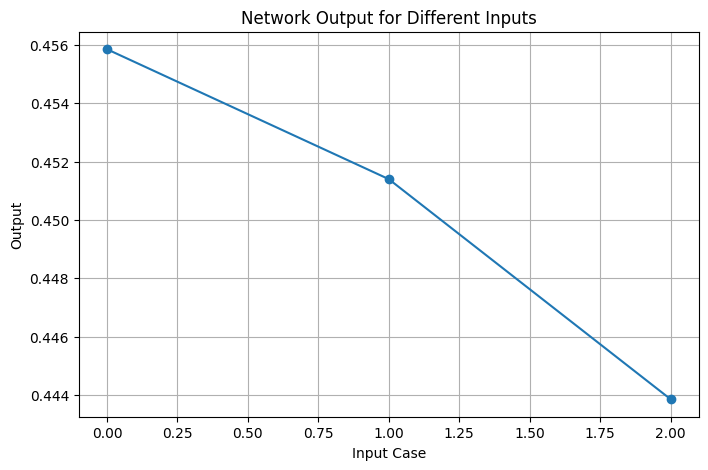

In [6]:
outputs = []

for inputs in inputs_list:
    outputs.append(network.forward(inputs))

plt.figure(figsize=(8, 5))
plt.plot(range(len(outputs)), outputs, marker='o')
plt.title("Network Output for Different Inputs")
plt.xlabel("Input Case")
plt.ylabel("Output")
plt.grid(True)
plt.show()